# Tarea 2 - Metaheurísticas: Job Shop Problem (JSP)

**Integrantes:**
- Felipe Chavez Gonzalez | 21.637.345-6
- Kamila Leiva Morales | 21.619.863-8
- Ignacio Matus de la Parra Rodriguez | 21.780.939-8
- Sofía Mena Cortés | 21.313.821-9

Este colab implementa el algoritmo **Simulated Annealing** para resolver el problema de Job Shop. El objetivo es minimizar el makespan (tiempo total de finalización de todos los trabajos).

Instancias: https://drive.google.com/drive/folders/1QUEYHiqBfpNwsJ0628PAXBXUNHQwrCxj

In [1]:
# Nuevo codigo mas ordenado y completo

import os
import time
import math
import random
import numpy as np
import matplotlib.pyplot as plt

def leer_instancia(nombre_archivo):
    """
    Lee el archivo de texto de la instancia y extrae la matriz de tiempos y máquinas requeridas.
    Ignora líneas en blanco y asume un formato donde los datos vienen intercalados (máquina, tiempo).
    """
    with open(nombre_archivo, 'r') as f:
        lineas = f.readlines()

    # Limpiamos las líneas para evitar errores por espacios extra al inicio o final
    lineas = [l.strip() for l in lineas if l.strip()]

    # La primera línea siempre nos indica cuántos trabajos y cuántas máquinas hay
    num_trabajos, num_maquinas = map(int, lineas[0].split())

    matriz_tiempos = []
    matriz_maquinas = []

    # Recorremos cada línea correspondiente a un trabajo
    for i in range(1, num_trabajos + 1):
        datos = list(map(int, lineas[i].split()))

        # Separamos los datos: las posiciones pares indican la máquina y las impares el tiempo de procesamiento
        maquinas = datos[0::2]
        tiempos = datos[1::2]

        matriz_maquinas.append(maquinas)
        matriz_tiempos.append(tiempos)

    return matriz_tiempos, matriz_maquinas

In [2]:
def generar_solucion_inicial(num_trabajos, num_maquinas):
    """
    Crea una solución base aleatoria. Generamos un arreglo donde el identificador
    de cada trabajo se repite tantas veces como máquinas tenga que visitar.
    Luego mezclamos este arreglo aleatoriamente.
    """
    solucion_actual = []
    for trabajo in range(num_trabajos):
        solucion_actual.extend([trabajo] * num_maquinas)

    random.shuffle(solucion_actual)
    return solucion_actual

def generar_vecino(solucion_actual):
    """
    Aplica el movimiento 'Swap' para explorar el vecindario de soluciones.
    Toma la solución actual, elige dos posiciones al azar y las intercambia
    para generar una nueva secuencia que el algoritmo evaluará.
    """
    solucion_vecina = solucion_actual.copy()
    posicion1, posicion2 = random.sample(range(len(solucion_vecina)), 2)

    # Intercambiamos los valores de las dos posiciones seleccionadas
    solucion_vecina[posicion1], solucion_vecina[posicion2] = solucion_vecina[posicion2], solucion_vecina[posicion1]

    return solucion_vecina

In [3]:
def calcular_makespan(solucion, matriz_tiempos, matriz_maquinas):
    """
    Calcula el makespan (tiempo total en que se terminan todos los trabajos) para una secuencia dada.
    Simula el proceso de producción respetando las restricciones de precedencia y la disponibilidad
    de cada máquina.
    """
    num_trabajos = len(matriz_tiempos)
    num_maquinas = len(matriz_tiempos[0])

    # Llevamos el registro del tiempo en que se desocupan las máquinas y los trabajos
    tiempo_fin_maquina = [0] * num_maquinas
    tiempo_fin_trabajo = [0] * num_trabajos

    # Controlamos por qué operación va cada trabajo (comenzando en 0)
    operacion_actual = [0] * num_trabajos

    for trabajo in solucion:
        op = operacion_actual[trabajo]
        maquina_requerida = matriz_maquinas[trabajo][op]
        tiempo_requerido = matriz_tiempos[trabajo][op]

        # Una operación solo puede empezar cuando su trabajo ha terminado la operación anterior
        # y cuando la máquina que necesita se encuentra disponible. Tomamos el mayor de estos dos tiempos.
        inicio_operacion = max(tiempo_fin_trabajo[trabajo], tiempo_fin_maquina[maquina_requerida])
        fin_operacion = inicio_operacion + tiempo_requerido

        # Actualizamos los tiempos de disponibilidad para el futuro
        tiempo_fin_trabajo[trabajo] = fin_operacion
        tiempo_fin_maquina[maquina_requerida] = fin_operacion
        operacion_actual[trabajo] += 1

    # El makespan corresponde al momento en que la última máquina terminó de trabajar
    return max(tiempo_fin_maquina)

In [4]:
def simulated_annealing(matriz_tiempos, matriz_maquinas, T_inicial, alpha, iteraciones_nivel, T_min, tiempo_maximo):
    """
    Ejecuta la metaheurística Simulated Annealing (Recocido Simulado) para buscar la mejor secuencia
    de trabajos. Inicia con alta temperatura para explorar libremente el espacio de búsqueda y
    lentamente se va enfriando para volverse más estricto y quedarse con las mejores soluciones.
    """
    num_trabajos = len(matriz_tiempos)
    num_maquinas = len(matriz_tiempos[0])

    # Paso 1: Generar la solución base y evaluar su calidad (makespan)
    solucion_actual = generar_solucion_inicial(num_trabajos, num_maquinas)
    makespan_actual = calcular_makespan(solucion_actual, matriz_tiempos, matriz_maquinas)

    # Guardamos esta primera solución como la mejor encontrada hasta el momento
    mejor_solucion = solucion_actual.copy()
    mejor_makespan = makespan_actual

    # Historial para graficar la convergencia del algoritmo en el tiempo
    historial_makespan = [makespan_actual]

    temperatura = T_inicial
    tiempo_inicio = time.time()

    # Paso 2: Bucle principal que se ejecuta mientras no nos congelemos y tengamos tiempo disponible
    while temperatura > T_min and (time.time() - tiempo_inicio) < tiempo_maximo:

        # Exploramos un número de vecinos definido por 'iteraciones_nivel' para la temperatura actual
        for _ in range(iteraciones_nivel):
            solucion_vecina = generar_vecino(solucion_actual)
            makespan_vecino = calcular_makespan(solucion_vecina, matriz_tiempos, matriz_maquinas)

            # Comparamos la calidad del vecino contra nuestra solución actual
            diferencia = makespan_vecino - makespan_actual

            # Criterio de aceptación: Si la vecina es mejor (diferencia < 0), la aceptamos inmediatamente.
            # Si es peor, la aceptamos con una cierta probabilidad que depende de la temperatura.
            if diferencia < 0 or random.random() < math.exp(-diferencia / temperatura):
                solucion_actual = solucion_vecina
                makespan_actual = makespan_vecino

                # Si esta nueva solución es la mejor de toda nuestra historia, la guardamos
                if makespan_actual < mejor_makespan:
                    mejor_solucion = solucion_actual.copy()
                    mejor_makespan = makespan_actual

        # Al final de cada nivel de temperatura, guardamos el estado actual para nuestro gráfico
        historial_makespan.append(makespan_actual)

        # Enfriamiento geométrico: Reducimos la temperatura multiplicándola por nuestro factor alpha (dejemoslo en 0.9 :p)
        temperatura *= alpha

    return mejor_solucion, mejor_makespan, historial_makespan

In [5]:
def graficar_convergencia(historial, archivo):
    """
    Dibuja un gráfico de línea mostrando cómo el Makespan fue disminuyendo
    a medida que avanzaban las iteraciones (niveles de temperatura).
    """
    plt.figure(figsize=(10, 4))
    plt.plot(historial, marker='o', markersize=3, linestyle='-', color='#1f77b4')
    plt.title(f"Convergencia de Simulated Annealing - {archivo}")
    plt.xlabel("Iteraciones (Ciclos de enfriamiento)")
    plt.ylabel("Makespan (Actual)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Ejecución de Instancias

Cargando archivo: instancia01_facil.txt
[INFO] Instancia: 6 trabajos y 6 máquinas.
[INFO] Ejecutando Simulated Annealing 10 veces...

[RESULTADOS FINALES] instancia01_facil.txt:
  -> Makespans de las 10 corridas: [58, 55, 55, 55, 55, 55, 55, 55, 55, 55]
  -> MEDIA: 55.30
  -> DESVIACIÓN ESTÁNDAR: 0.90



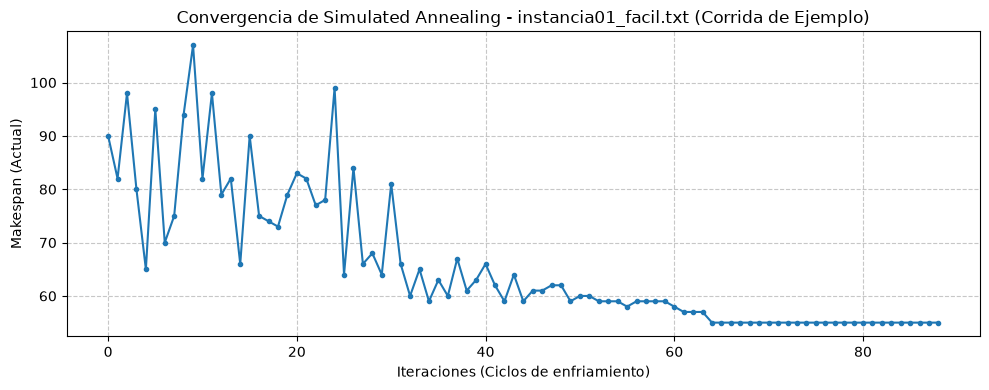



Cargando archivo: instancia02_media.txt
[INFO] Instancia: 15 trabajos y 10 máquinas.
[INFO] Ejecutando Simulated Annealing 10 veces...

[RESULTADOS FINALES] instancia02_media.txt:
  -> Makespans de las 10 corridas: [1080, 1093, 1093, 1073, 1077, 1071, 1054, 1057, 1073, 1080]
  -> MEDIA: 1075.10
  -> DESVIACIÓN ESTÁNDAR: 12.21



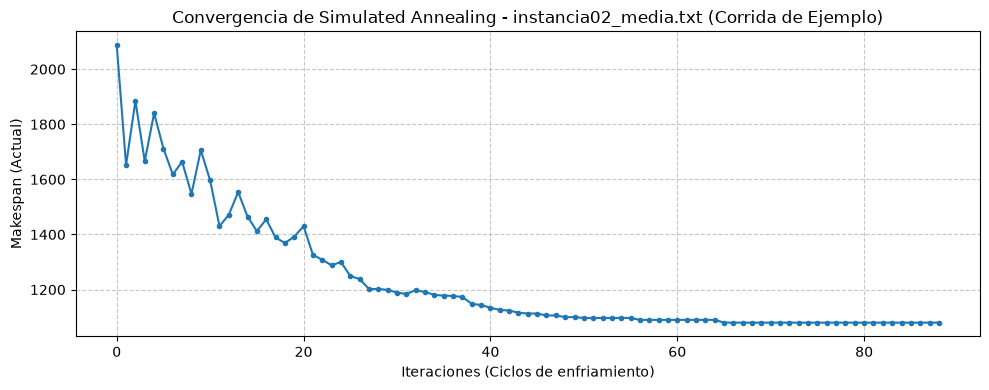



Cargando archivo: instancia03_dificil.txt
[INFO] Instancia: 50 trabajos y 10 máquinas.
[INFO] Ejecutando Simulated Annealing 10 veces...

[RESULTADOS FINALES] instancia03_dificil.txt:
  -> Makespans de las 10 corridas: [2794, 2809, 2794, 2794, 2806, 2838, 2810, 2823, 2794, 2794]
  -> MEDIA: 2805.60
  -> DESVIACIÓN ESTÁNDAR: 14.34



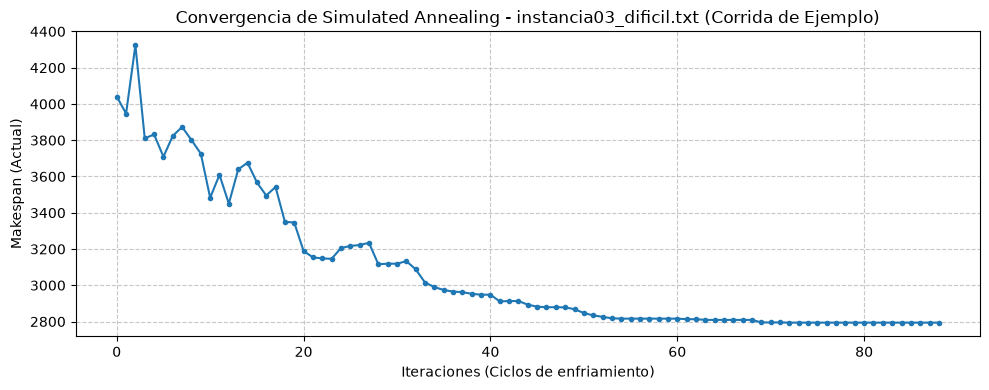

In [6]:
# Lista de instancias a resolver
archivos_instancias = [
    'instancia01_facil.txt',
    'instancia02_media.txt',
    'instancia03_dificil.txt'
]

T_inicial = 100            # Alta temperatura para permitir diversificación inicial
factor_enfriamiento = 0.9  # Reducimos lentamente para asegurar buen tiempo de búsqueda y calidad (lo cambien en el informe tambien)
iteraciones_nivel = 100    # Tiempo de exploración por cada escalón de temperatura
T_minima = 0.01            # Punto de congelación donde ya no se aceptan peores soluciones
tiempo_limite = 60         # Tiempo máximo de ejecución en segundos
num_ejecuciones = 10

# Diccionario para almacenar los resultados y graficar el boxplot al final
resultados_boxplot = {}

for archivo in archivos_instancias:
    if os.path.exists(archivo):
        print(f"=======================================================")
        print(f"Cargando archivo: {archivo}")
        matriz_tiempos, matriz_maquinas = leer_instancia(archivo)
        
        trabajos = len(matriz_tiempos)
        maquinas = len(matriz_tiempos[0]) if trabajos > 0 else 0
        print(f"[INFO] Instancia: {trabajos} trabajos y {maquinas} máquinas.")
        print(f"[INFO] Ejecutando Simulated Annealing {num_ejecuciones} veces...")
        
        makespans_obtenidos = []
        historial_ejemplo = None
        
        # Realizamos las 10 ejecuciones independientes
        for i in range(num_ejecuciones):
            _, mejor_makespan, historial = simulated_annealing(
                matriz_tiempos, matriz_maquinas, T_inicial, factor_enfriamiento, 
                iteraciones_nivel, T_minima, tiempo_limite
            )
            makespans_obtenidos.append(mejor_makespan)
            
            # Guardamos el historial de la última ejecución para graficar la convergencia de ejemplo
            if i == num_ejecuciones - 1:
                historial_ejemplo = historial
        
        # Guardamos en el diccionario general
        resultados_boxplot[archivo] = makespans_obtenidos
        
        # Calculamos Media y Desviación Estándar
        media = np.mean(makespans_obtenidos)
        desviacion = np.std(makespans_obtenidos)

        print(f"\n[RESULTADOS FINALES] {archivo}:")
        print(f"  -> Makespans de las {num_ejecuciones} corridas: {makespans_obtenidos}")
        print(f"  -> MEDIA: {media:.2f}")
        print(f"  -> DESVIACIÓN ESTÁNDAR: {desviacion:.2f}\n")
        
        # Mostramos la convergencia de una de las corridas
        graficar_convergencia(historial_ejemplo, f"{archivo} (Corrida de Ejemplo)")
        print("\n")
        
    else:
        print(f"\n[ERROR] No se pudo localizar el archivo: {archivo}")

## Análisis Gráfico: Gráfico de Cajas (Boxplot)

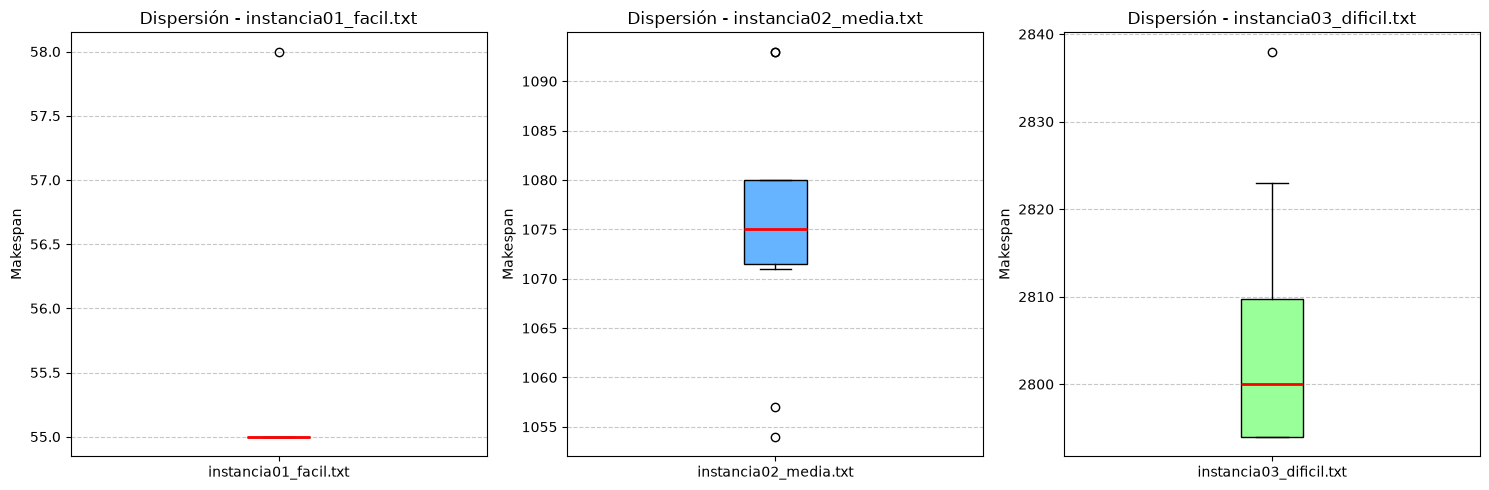

In [7]:
def graficar_boxplot(resultados):
    """
    Genera gráficos de cajas (Boxplot) independientes para cada instancia,
    lo que permite visualizar correctamente la dispersión sin problemas de escala.
    """
    if not resultados:
        return
        
    etiquetas = list(resultados.keys())
    datos = list(resultados.values())
    num_instancias = len(resultados)
    
    # Creamos subplots horizontales, cada uno con su propia escala Y
    fig, axes = plt.subplots(1, num_instancias, figsize=(15, 5))
    
    # Si solo hay 1 instancia, axes no es una lista
    if num_instancias == 1:
        axes = [axes]
        
    colores = ['#ff9999', '#66b3ff', '#99ff99']
    
    for i in range(num_instancias):
        ax = axes[i]
        # Se remueve el parámetro 'labels' obsoleto y se configuran directamente los ticks
        caja = ax.boxplot([datos[i]], patch_artist=True)
        ax.set_xticks([1])
        ax.set_xticklabels([etiquetas[i]])
        
        # Pintamos la caja
        color = colores[i % len(colores)]
        for patch in caja['boxes']:
            patch.set_facecolor(color)
            
        # Destacamos la mediana
        for median in caja['medians']:
            median.set(color='red', linewidth=2)
            
        ax.set_title(f"Dispersión - {etiquetas[i]}")
        ax.set_ylabel("Makespan")
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
    plt.tight_layout()
    plt.show()

# Dibujamos los boxplots usando el diccionario general de resultados
graficar_boxplot(resultados_boxplot)